In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lmfit import Model
import pathlib as Path
from scipy.signal import savgol_filter

### Information of dataset
- there are 87 participants and at this time 5 variables (17 Aug)


### Data preperation steps
split the data in 80/20,
cross validation (CV)

1. Cleaning data
- Missing data
- Outliers
2. Formating
- Encoding categorical data
- Scaling data
- Standardization
- Discretization (binning data)
3. Data engineering

In [2]:
from pathlib import Path
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_09_09_data_timeseries.csv')
df = pd.read_csv(x).drop(columns='Unnamed: 0')
df

,condition_id,condition,category,valence,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix),RDX_rolling,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad
0,ACP_10,ACP,objet,negative,0.000000,-0.203103,10.545351,-1.557942,7.259980,-1.557942,-44.339866,329.0,-12.022054,1655.0,0.024372
1,ACP_10,ACP,objet,negative,0.003335,0.411109,11.118102,-0.912476,7.956384,-1.235209,-44.339866,329.0,-12.022054,1655.0,0.024372
2,ACP_10,ACP,objet,negative,0.006670,1.032096,11.620336,-0.216857,8.562834,-0.895758,-44.339866,329.0,-12.022054,1655.0,0.024372
3,ACP_10,ACP,objet,negative,0.010006,1.631694,11.941326,0.494356,8.978518,-0.548230,-44.339866,329.0,-12.022054,1655.0,0.024372
4,ACP_10,ACP,objet,negative,0.013341,2.171882,11.973220,1.177103,9.107632,-0.203163,-44.339866,329.0,-12.022054,1655.0,0.024372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933627,DFT_9,DFT,visage,positive,5.959993,NaN,NaN,-23.547614,NaN,-23.149807,-48.965409,317.0,-13.618955,1256.0,0.037643
933628,DFT_9,DFT,visage,positive,5.963328,NaN,NaN,-24.026216,NaN,-23.152393,-48.965409,317.0,-13.618955,1256.0,0.037643
933629,DFT_9,DFT,visage,positive,5.966663,NaN,NaN,-24.564667,NaN,-23.182579,-48.965409,317.0,-13.618955,1256.0,0.037643
933630,DFT_9,DFT,visage,positive,5.969998,NaN,NaN,-25.144319,NaN,-23.244083,-48.965409,317.0,-13.618955,1256.0,0.037643


In [3]:
df['RDX2_min'] = df['RDX_min']**2
df['RDX2_max'] = df['RDX_max']**2

df.head()

,condition_id,condition,category,valence,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix),RDX_rolling,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad,RDX2_min,RDX2_max
0,ACP_10,ACP,objet,negative,0.000000,-0.203103,10.545351,-1.557942,7.259980,-1.557942,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
1,ACP_10,ACP,objet,negative,0.003335,0.411109,11.118102,-0.912476,7.956384,-1.235209,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
2,ACP_10,ACP,objet,negative,0.006670,1.032096,11.620336,-0.216857,8.562834,-0.895758,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
3,ACP_10,ACP,objet,negative,0.010006,1.631694,11.941326,0.494356,8.978518,-0.548230,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
4,ACP_10,ACP,objet,negative,0.013341,2.171882,11.973220,1.177103,9.107632,-0.203163,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776


##### Remove NaNs

In [4]:
rdx_data = df.dropna(subset=['RDX_rolling'], how='any')
rdx_data

,condition_id,condition,category,valence,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix),RDX_rolling,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad,RDX2_min,RDX2_max
0,ACP_10,ACP,objet,negative,0.000000,-0.203103,10.545351,-1.557942,7.259980,-1.557942,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
1,ACP_10,ACP,objet,negative,0.003335,0.411109,11.118102,-0.912476,7.956384,-1.235209,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
2,ACP_10,ACP,objet,negative,0.006670,1.032096,11.620336,-0.216857,8.562834,-0.895758,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
3,ACP_10,ACP,objet,negative,0.010006,1.631694,11.941326,0.494356,8.978518,-0.548230,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
4,ACP_10,ACP,objet,negative,0.013341,2.171882,11.973220,1.177103,9.107632,-0.203163,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933627,DFT_9,DFT,visage,positive,5.959993,NaN,NaN,-23.547614,NaN,-23.149807,-48.965409,317.0,-13.618955,1256.0,0.037643,2397.611290,185.475945
933628,DFT_9,DFT,visage,positive,5.963328,NaN,NaN,-24.026216,NaN,-23.152393,-48.965409,317.0,-13.618955,1256.0,0.037643,2397.611290,185.475945
933629,DFT_9,DFT,visage,positive,5.966663,NaN,NaN,-24.564667,NaN,-23.182579,-48.965409,317.0,-13.618955,1256.0,0.037643,2397.611290,185.475945
933630,DFT_9,DFT,visage,positive,5.969998,NaN,NaN,-25.144319,NaN,-23.244083,-48.965409,317.0,-13.618955,1256.0,0.037643,2397.611290,185.475945


##### One hot encoder

In [5]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
ohetransform = ohe.fit_transform(rdx_data[['category', 'valence']])
rdx_data = pd.concat([rdx_data, ohetransform], axis=1).drop(columns=['category', 'valence'])
rdx_data

,condition_id,condition,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix),RDX_rolling,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad,RDX2_min,RDX2_max,category_objet,category_visage,valence_negative,valence_neutre,valence_positive
0,ACP_10,ACP,0.000000,-0.203103,10.545351,-1.557942,7.259980,-1.557942,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776,1.0,0.0,1.0,0.0,0.0
1,ACP_10,ACP,0.003335,0.411109,11.118102,-0.912476,7.956384,-1.235209,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776,1.0,0.0,1.0,0.0,0.0
2,ACP_10,ACP,0.006670,1.032096,11.620336,-0.216857,8.562834,-0.895758,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776,1.0,0.0,1.0,0.0,0.0
3,ACP_10,ACP,0.010006,1.631694,11.941326,0.494356,8.978518,-0.548230,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776,1.0,0.0,1.0,0.0,0.0
4,ACP_10,ACP,0.013341,2.171882,11.973220,1.177103,9.107632,-0.203163,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933627,DFT_9,DFT,5.959993,NaN,NaN,-23.547614,NaN,-23.149807,-48.965409,317.0,-13.618955,1256.0,0.037643,2397.611290,185.475945,0.0,1.0,0.0,0.0,1.0
933628,DFT_9,DFT,5.963328,NaN,NaN,-24.026216,NaN,-23.152393,-48.965409,317.0,-13.618955,1256.0,0.037643,2397.611290,185.475945,0.0,1.0,0.0,0.0,1.0
933629,DFT_9,DFT,5.966663,NaN,NaN,-24.564667,NaN,-23.182579,-48.965409,317.0,-13.618955,1256.0,0.037643,2397.611290,185.475945,0.0,1.0,0.0,0.0,1.0
933630,DFT_9,DFT,5.969998,NaN,NaN,-25.144319,NaN,-23.244083,-48.965409,317.0,-13.618955,1256.0,0.037643,2397.611290,185.475945,0.0,1.0,0.0,0.0,1.0


##### Train, test, split

In [12]:
from sklearn.model_selection import GroupShuffleSplit

X = rdx_data.loc[:, ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'RDX2_min', 'RDX2_max', 'category_objet',  'category_visage', 'valence_negative',
   'valence_neutre', 'valence_positive']].iloc[0::1792, :].reset_index().drop(columns='index')
y = rdx_data.loc[:, 'condition'].iloc[0::1792].reset_index().drop(columns='index')

id = rdx_data.condition_id.iloc[0::1792].reset_index().drop(columns='index')

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in gss.split(X, groups=id):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    id_train = id.iloc[train_idx]
    id_test = id.iloc[test_idx]

### Cleaning data

##### Missing data

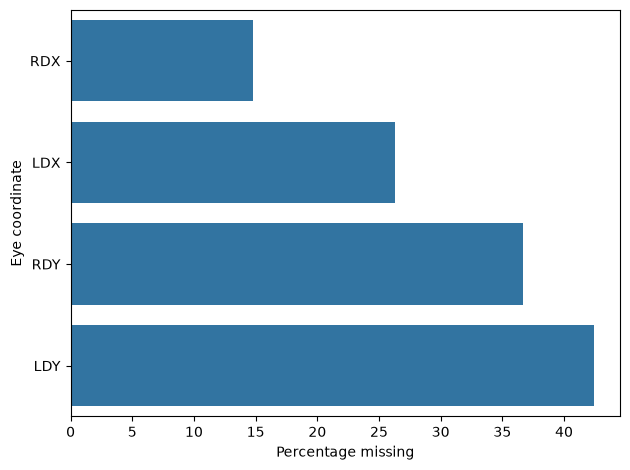

In [13]:
# highlight why RDX was chosen over the others
missing_values = {
    'RDX': df['RDX (pix)'].isna().mean()*100,
    'LDX': df['LDX (pix)'].isna().mean()*100,
    'RDY': df['RDY (pix)'].isna().mean()*100,
    'LDY': df['LDY (pix)'].isna().mean()*100
}


ax = sns.barplot(data = missing_values, orient='h')
ax.set(xlabel = 'Percentage missing', ylabel='Eye coordinate')
# plt.savefig('figures/missing_pupil.png', dpi=150)
plt.tight_layout()

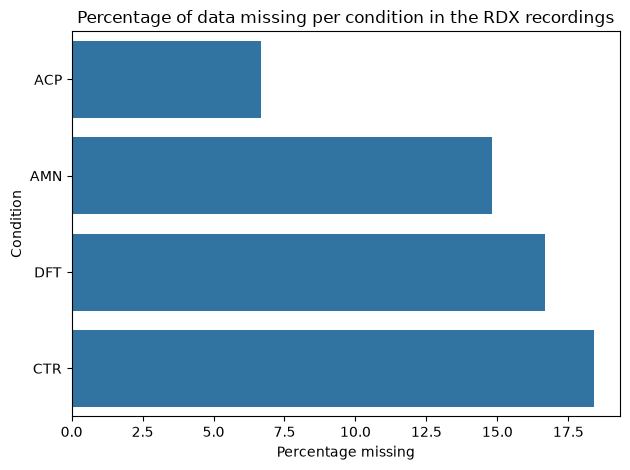

In [14]:
missing_values = {
    'ACP': df[df.condition=='ACP']['RDX (pix)'].isna().mean()*100,
    'AMN': df[df.condition=='AMN']['RDX (pix)'].isna().mean()*100,
    'DFT': df[df.condition=='DFT']['RDX (pix)'].isna().mean()*100,
    'CTR': df[df.condition=='CTR']['RDX (pix)'].isna().mean()*100
}


ax = sns.barplot(data = missing_values, orient='h')
ax.set(xlabel='Percentage missing', ylabel='Condition', title='Percentage of data missing per condition in the RDX recordings')
# plt.savefig('figures/missing_rdx.png', dpi=150)
plt.tight_layout()

##### Outliers

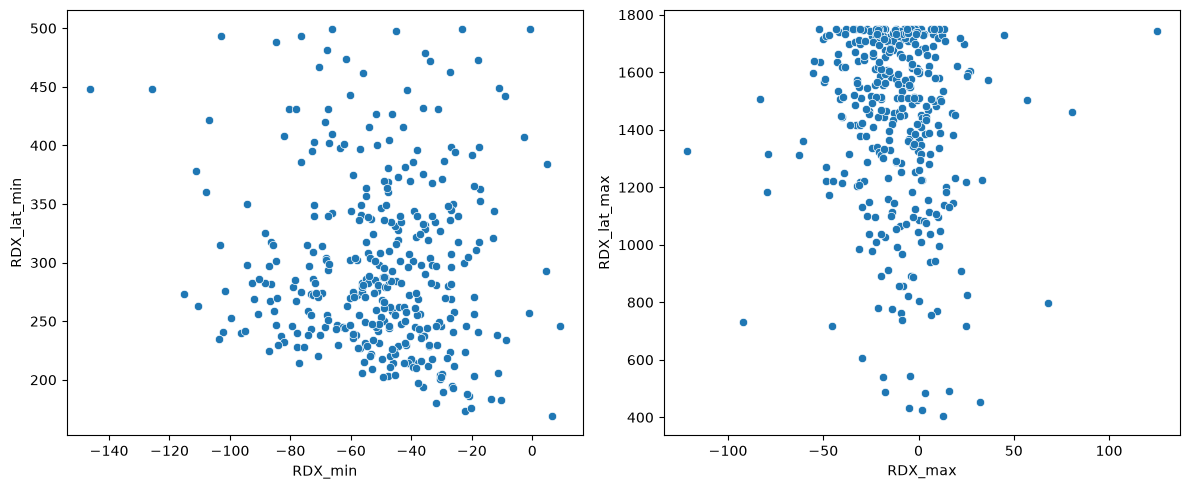

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


sns.scatterplot(X_train, x='RDX_min', y='RDX_lat_min', ax=ax[0])
sns.scatterplot(X_train, x='RDX_max', y='RDX_lat_max', ax=ax[1])
plt.tight_layout()

KeyboardInterrupt: 

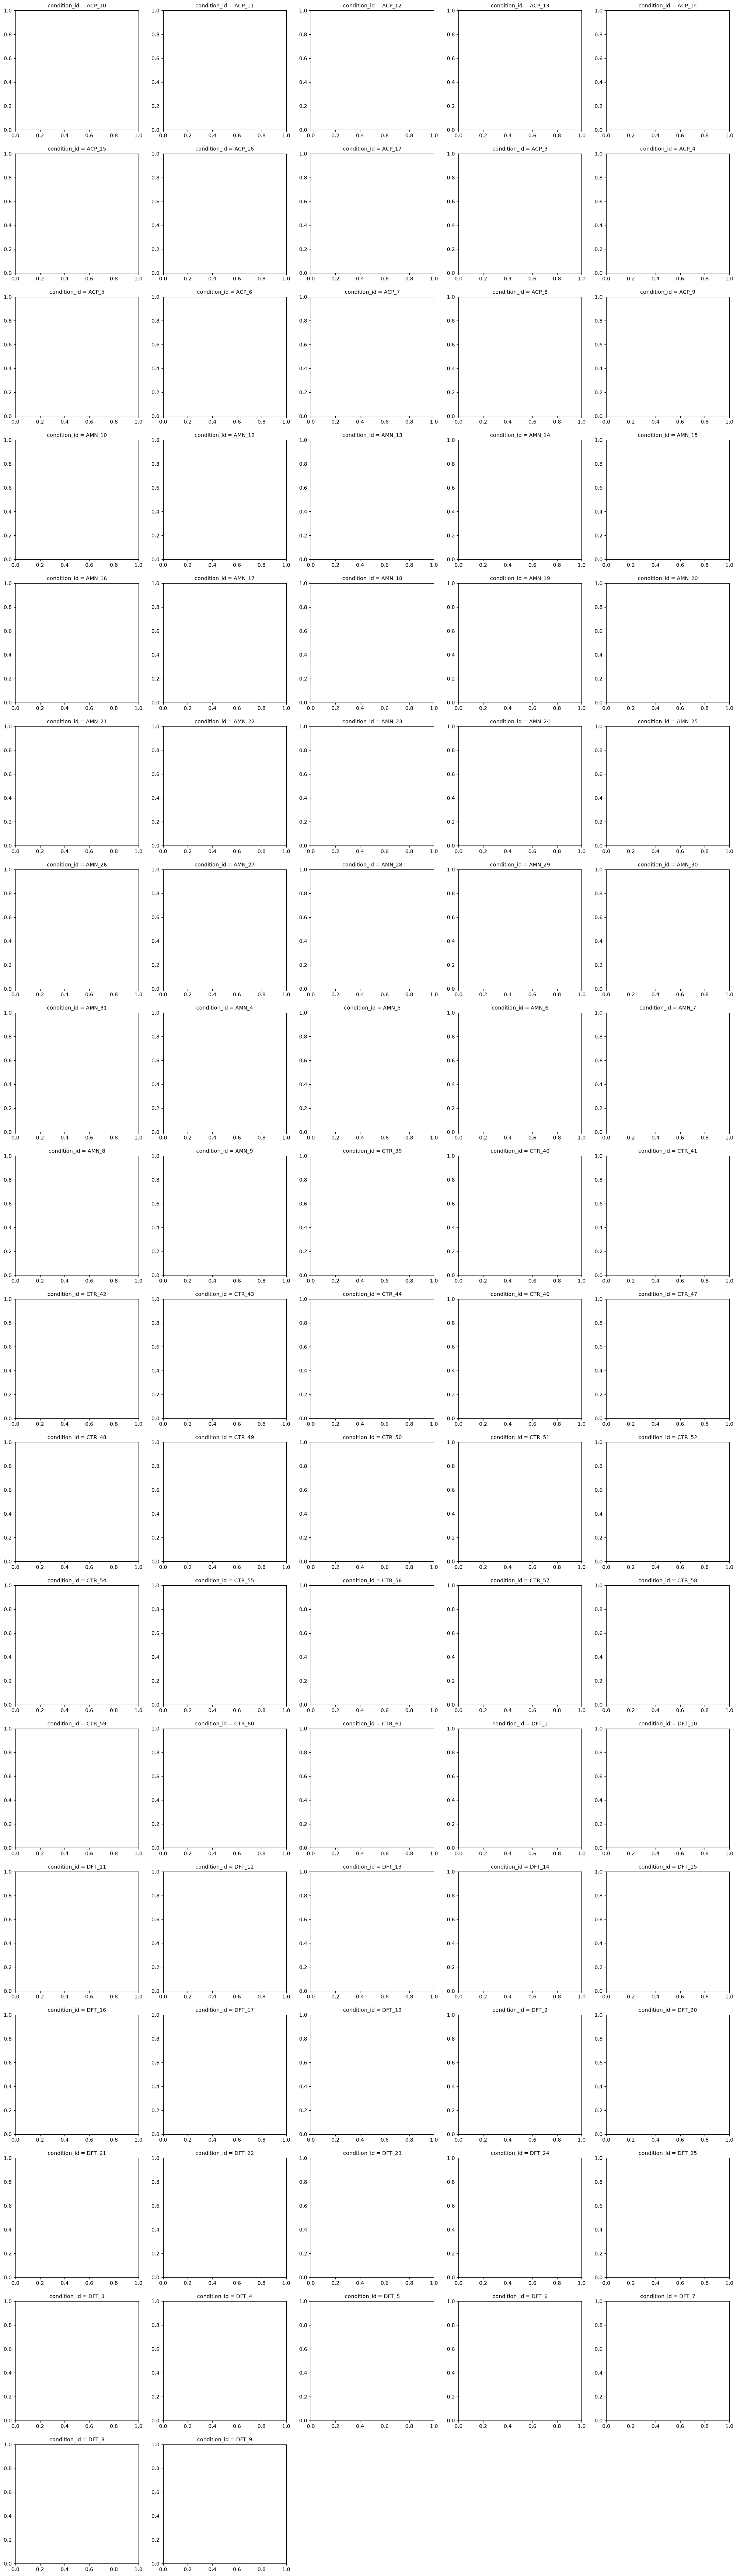

In [10]:
sns.relplot(df, x='time', y='RDX_rolling', col_wrap=5, col='condition_id', hue='valence', kind='line', errorbar=None)

##### Scaling

In [16]:
from sklearn.preprocessing import RobustScaler

before_scaled = X_train.copy()

transformer = RobustScaler().set_output(transform="pandas").fit(X_train.loc[:, ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'RDX2_min', 'RDX2_max']])
X_train = transformer.transform(X_train.loc[:, ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'RDX2_min', 'RDX2_max']])

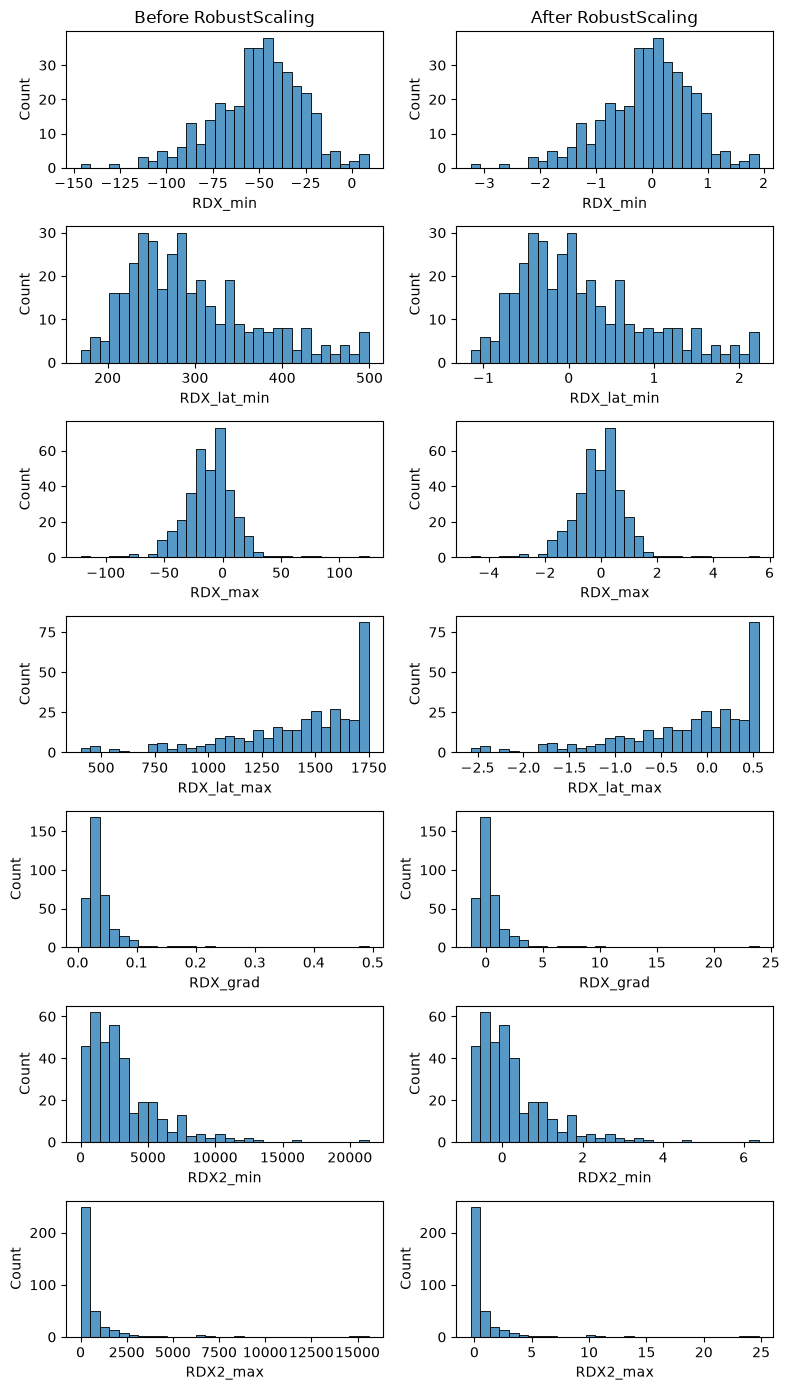

In [18]:
fig, ax = plt.subplots(7, 2, figsize=(8, 14))

sns.histplot(before_scaled, x='RDX_min', bins=30, ax=ax[0][0])
sns.histplot(X_train, x='RDX_min', bins=30, ax=ax[0][1])

sns.histplot(before_scaled, x='RDX_lat_min', bins=30, ax=ax[1][0])
sns.histplot(X_train, x='RDX_lat_min', bins=30, ax=ax[1][1])

sns.histplot(before_scaled, x='RDX_max', bins=30, ax=ax[2][0])
sns.histplot(X_train, x='RDX_max', bins=30, ax=ax[2][1])

sns.histplot(before_scaled, x='RDX_lat_max', bins=30, ax=ax[3][0])
sns.histplot(X_train, x='RDX_lat_max', bins=30, ax=ax[3][1])

sns.histplot(before_scaled, x='RDX_grad', bins=30, ax=ax[4][0])
sns.histplot(X_train, x='RDX_grad', bins=30, ax=ax[4][1])

sns.histplot(before_scaled, x='RDX2_min', bins=30, ax=ax[5][0])
sns.histplot(X_train, x='RDX2_min', bins=30, ax=ax[5][1])

sns.histplot(before_scaled, x='RDX2_max', bins=30, ax=ax[6][0])
sns.histplot(X_train, x='RDX2_max', bins=30, ax=ax[6][1])

ax[0][0].set_title('Before RobustScaling')
ax[0][1].set_title('After RobustScaling')

plt.tight_layout()

In [15]:
X_train.describe().round(3)

,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad
count,354.000,354.000,354.000,354.000,354.000
mean,-0.067,0.155,-0.059,-0.193,0.446
std,0.784,0.755,0.958,0.723,1.843
min,-3.248,-1.151,-4.650,-2.576,-1.333
25%,-0.538,-0.402,-0.544,-0.590,-0.364
50%,0.000,0.000,-0.000,0.000,0.000
75%,0.462,0.598,0.456,0.410,0.636
max,1.911,2.225,5.611,0.559,23.934


##### Checking features - correlation

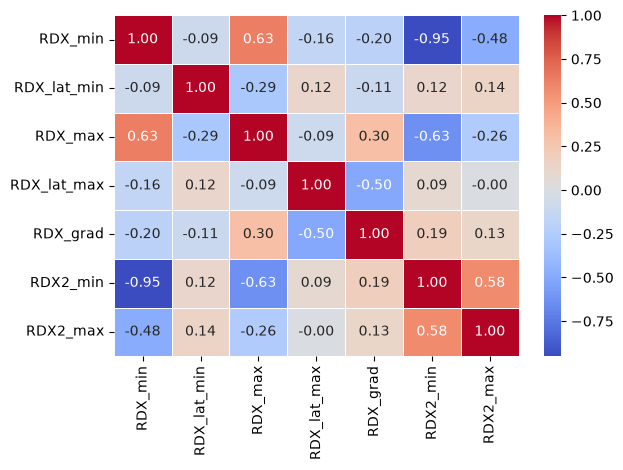

In [19]:
matrix = X_train.loc[:, ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'RDX2_min', 'RDX2_max']].corr()
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.tight_layout()

##### Checking features - PCA

In [20]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_train)

In [21]:
pca.explained_variance_ratio_

array([0.52034615, 0.28076723, 0.10765553, 0.04364726, 0.03578181,
       0.00968286, 0.00211915])

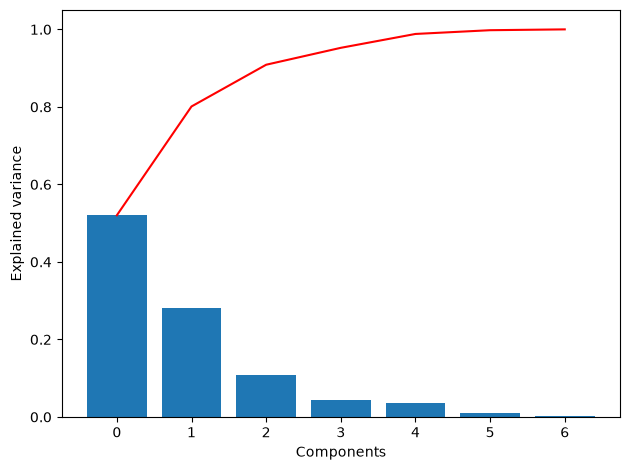

In [22]:
plt.bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)
plt.plot(range(len(pca.explained_variance_ratio_)), np.cumsum(pca.explained_variance_ratio_), c='r')
plt.xlabel('Components')
plt.ylabel('Explained variance')
plt.tight_layout()

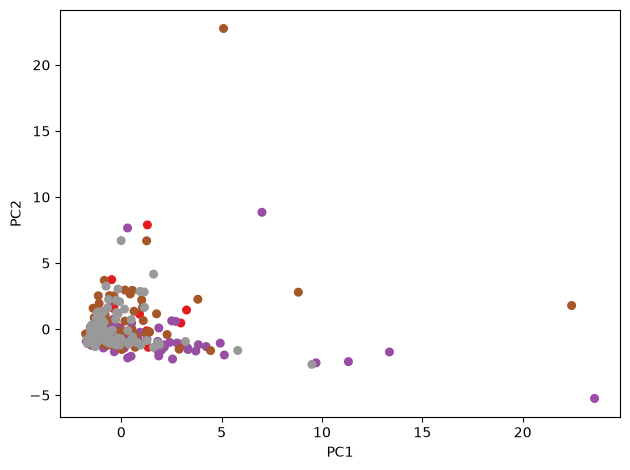

In [23]:
codes, _ = pd.factorize(y_train.loc[:, 'condition'])
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=codes, s=30, cmap="Set1")
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()

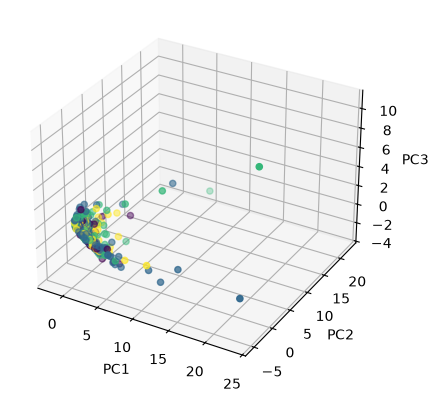

In [24]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=codes)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.show()

In [28]:
save = rdx_data.loc[:, ['condition', 'condition_id', 'RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'RDX2_min', 'RDX2_max', 'category_objet',  'category_visage', 'valence_negative',
   'valence_neutre', 'valence_positive']]

save.to_csv('2026_09_09_variable_trainingset_2.csv')